In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LAUNCH = "2025-10-01"
TRUE_LIFT = 0.15

df = pd.read_csv("../data/geo_test.csv", parse_dates=["date"])
df.head()

,market,baseline,group,date,day_of_week,days_since_start,counterfactual,post,treated,registrations
0,market_00,90,control,2025-01-01,2,0,83.813094,False,False,84
1,market_00,90,control,2025-01-02,3,1,92.701333,False,False,93
2,market_00,90,control,2025-01-03,4,2,83.179141,False,False,83
3,market_00,90,control,2025-01-04,5,3,81.998930,False,False,82
4,market_00,90,control,2025-01-05,6,4,76.346842,False,False,76


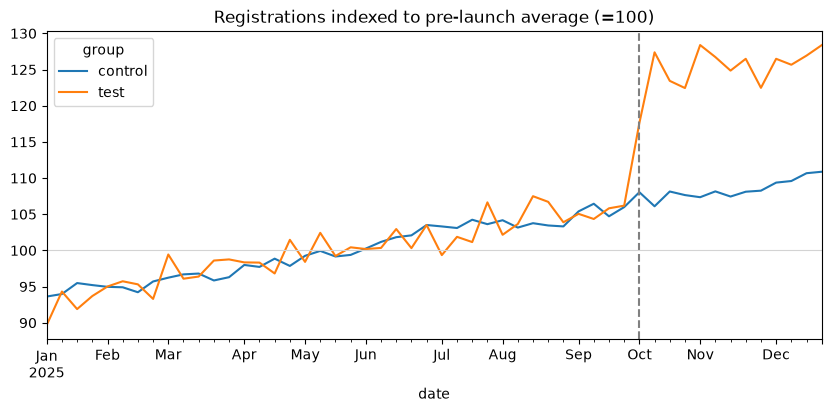

In [2]:
weekly_avg = (
    df.groupby([pd.Grouper(key="date", freq="W"), "group"])["registrations"]
    .mean()
    .unstack()
    .iloc[:-1]
)

pre_mean = df[~df["post"]].groupby("group")["registrations"].mean()
indexed = weekly_avg / pre_mean * 100

ax = indexed.plot(figsize=(10, 4), title="Registrations indexed to pre-launch average (=100)")
ax.axvline(pd.Timestamp(LAUNCH), color="gray", linestyle="--")
ax.axhline(100, color="lightgray", linewidth=0.8)
plt.show()

In [3]:
def did_lift(data, launch_date):
    d = data.copy()
    d["post"] = d["date"] >= launch_date
    means = d.groupby(["group", "post"])["registrations"].mean().unstack()
    growth = means[True] / means[False]
    return growth["test"] / growth["control"] - 1

print(f"Real launch: {did_lift(df, LAUNCH):.1%}")

pre_only = df[df["date"] < LAUNCH]
for fake_date in ["2025-04-01", "2025-06-01", "2025-08-01"]:
    print(f"Placebo {fake_date}: {did_lift(pre_only, fake_date):.1%}")

Real launch: 15.8%
Placebo 2025-04-01: 0.1%
Placebo 2025-06-01: -0.5%
Placebo 2025-08-01: 0.5%


In [6]:
import statsmodels.formula.api as smf

df["log_reg"] = np.log(df["registrations"])
df["is_test"] = (df["group"] == "test").astype(int)
df["post_int"] = df["post"].astype(int)

model = smf.ols(
    "log_reg ~ is_test:post_int + C(market) + C(date)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(df["market"])[0]})

coef = model.params["is_test:post_int"]
lo, hi = model.conf_int().loc["is_test:post_int"]
print(f"Lift: {np.exp(coef)-1:.1%}  (95% CI: {np.exp(lo)-1:.1%} to {np.exp(hi)-1:.1%})")
print(f"p-value: {model.pvalues['is_test:post_int']:.4f}")

Lift: 15.4%  (95% CI: 14.0% to 16.8%)
p-value: 0.0000
